# XAU Depth Volatility Analysis

Notebook này đọc dữ liệu `XAU` từ SQLite, bung `depth_bands_json` thành bảng theo các band `0.5, 1, 1.5, 2, 3, 4, 5`, rồi tập trung đo và vẽ biến động depth ở tần suất 1 giây.

Các câu hỏi chính:
- Depth của từng band thay đổi mạnh hay nhẹ theo thời gian.
- Band nào biến động nhất.
- Biến động depth có đi cùng spread và mid-price hay không.

In [81]:
from __future__ import annotations

import json
import sqlite3
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [ ]:
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DB_PATH = ROOT / "data" / "snapshots.db"
MARKET = "XAU"
DEPTH_BANDS = [0.5, 1, 1.5, 2, 3, 4, 5]
TIMEZONE = "Asia/Ho_Chi_Minh"
ROLLING_WINDOWS = {
    "30s": 30,
    "60s": 60,
    "300s": 300,
}
DEFAULT_ROLLING_WINDOW = "60s"
KEY_BANDS = [0.5, 1, 1.5, 2, 5]
CONTEXT_BAND = 1
# DEFAULT_LOOKBACK = pd.Timedelta(days=7)
DEFAULT_LOOKBACK = pd.Timedelta(hours=1)

# Plot scaling controls for large datasets.
MAX_PLOT_POINTS = 5000
HEATMAP_MAX_COLUMNS = 2000

# Override these two values to evaluate a custom time range.
now_utc = pd.Timestamp.now(tz="UTC")
endTs = int(now_utc.timestamp() * 1000)
startTs = int((now_utc - DEFAULT_LOOKBACK).timestamp() * 1000)

assert startTs < endTs, "startTs must be smaller than endTs"
assert DB_PATH.exists(), f"Database not found: {DB_PATH}"
DEFAULT_WINDOW_SIZE = ROLLING_WINDOWS[DEFAULT_ROLLING_WINDOW]
DB_PATH

PosixPath('/Users/trungnguyen/Desktop/oraichain/lighter-orderbook-snapshot/data/snapshots.db')

## Load and flatten data

In [83]:
query = """
SELECT
    ts_ms,
    market,
    best_bid,
    best_ask,
    spread,
    mid_price,
    depth_bands_json
FROM snapshots
WHERE market = ?
  AND ts_ms BETWEEN ? AND ?
ORDER BY ts_ms ASC
"""

with sqlite3.connect(DB_PATH) as conn:
    raw_df = pd.read_sql_query(query, conn, params=(MARKET, startTs, endTs))

if raw_df.empty:
    raise ValueError(
        f"No rows found for market={MARKET} in range startTs={startTs}, endTs={endTs}"
    )

raw_df["timestamp"] = pd.to_datetime(raw_df["ts_ms"], unit="ms", utc=True).dt.tz_convert(TIMEZONE)
raw_df["depth_bands"] = raw_df["depth_bands_json"].apply(json.loads)
raw_df = raw_df.drop(columns=["depth_bands_json"])
raw_df.head()

,ts_ms,market,best_bid,best_ask,spread,mid_price,timestamp,depth_bands
0,1776609631523,XAU,NaN,NaN,NaN,NaN,2026-04-19 21:40:31.523000+07:00,[]
1,1776609632524,XAU,4803.69,4803.70,0.01,4803.695,2026-04-19 21:40:32.524000+07:00,"[{'band': 0.5, 'bidDepth': 0.5453, 'askDepth':..."
2,1776609633525,XAU,4803.69,4803.89,0.20,4803.790,2026-04-19 21:40:33.525000+07:00,"[{'band': 0.5, 'bidDepth': 0.24530000000000002..."
3,1776609634525,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:34.525000+07:00,"[{'band': 0.5, 'bidDepth': 5.8854999999999995,..."
4,1776609635526,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:35.526000+07:00,"[{'band': 0.5, 'bidDepth': 5.8854999999999995,..."


In [84]:
def band_label(band: float) -> str:
    return str(band).replace(".", "_")


def flatten_depth_bands(df: pd.DataFrame, expected_bands: list[float]) -> pd.DataFrame:
    records: list[dict[str, float]] = []

    for depth_items in df["depth_bands"]:
        row: dict[str, float] = {}
        by_band = {float(item["band"]): item for item in depth_items}

        for band in expected_bands:
            item = by_band.get(float(band), {})
            suffix = band_label(band)
            row[f"bid_depth_{suffix}"] = item.get("bidDepth", np.nan)
            row[f"ask_depth_{suffix}"] = item.get("askDepth", np.nan)
            row[f"total_depth_{suffix}"] = item.get("totalDepth", np.nan)

        records.append(row)

    flat_df = pd.DataFrame.from_records(records, index=df.index)
    result = pd.concat([df.drop(columns=["depth_bands"]), flat_df], axis=1)
    return result.sort_values("timestamp").reset_index(drop=True)


df = flatten_depth_bands(raw_df, DEPTH_BANDS)
df.head()

,ts_ms,market,best_bid,best_ask,spread,mid_price,timestamp,bid_depth_0_5,ask_depth_0_5,total_depth_0_5,bid_depth_1,ask_depth_1,total_depth_1,bid_depth_1_5,ask_depth_1_5,total_depth_1_5,bid_depth_2,ask_depth_2,total_depth_2,bid_depth_3,ask_depth_3,total_depth_3,bid_depth_4,ask_depth_4,total_depth_4,bid_depth_5,ask_depth_5,total_depth_5
0,1776609631523,XAU,NaN,NaN,NaN,NaN,2026-04-19 21:40:31.523000+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1776609632524,XAU,4803.69,4803.70,0.01,4803.695,2026-04-19 21:40:32.524000+07:00,0.5453,0.1393,0.6846,4.7086,0.1393,4.8479,7.9426,2.1251,10.0677,10.2285,7.8450,18.0735,16.7328,13.3924,30.1252,22.0471,25.4415,47.4886,22.3471,29.0751,51.4222
2,1776609633525,XAU,4803.69,4803.89,0.20,4803.790,2026-04-19 21:40:33.525000+07:00,0.2453,0.1393,0.3846,4.4086,0.1393,4.5479,7.6426,4.0109,11.6535,9.9285,8.1631,18.0916,16.4328,21.7797,38.2125,21.7471,25.9619,47.7090,22.0471,34.9905,57.0376
3,1776609634525,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:34.525000+07:00,5.8855,0.1393,6.0248,5.8855,0.1393,6.0248,7.9195,4.0109,11.9304,9.9798,8.1631,18.1429,16.1841,21.7797,37.9638,21.7984,25.9619,47.7603,21.7984,34.9905,56.7889
4,1776609635526,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:35.526000+07:00,5.8855,0.1393,6.0248,5.8855,0.1393,6.0248,7.9195,4.0109,11.9304,9.9798,8.1631,18.1429,16.1841,21.7797,37.9638,21.7984,25.9619,47.7603,21.7984,34.9905,56.7889


## Data quality checks

In [85]:
missing_band_rows = []
for band in DEPTH_BANDS:
    suffix = band_label(band)
    total_col = f"total_depth_{suffix}"
    if df[total_col].isna().any():
        missing_band_rows.append(band)

consistency_checks = []
for band in DEPTH_BANDS:
    suffix = band_label(band)
    total_col = f"total_depth_{suffix}"
    bid_col = f"bid_depth_{suffix}"
    ask_col = f"ask_depth_{suffix}"
    max_error = (df[total_col] - (df[bid_col] + df[ask_col])).abs().max()
    consistency_checks.append({"band": band, "max_total_error": max_error})

quality_summary = {
    "row_count": int(len(df)),
    "timestamp_start": df["timestamp"].min(),
    "timestamp_end": df["timestamp"].max(),
    "missing_band_rows": missing_band_rows,
}

quality_summary, pd.DataFrame(consistency_checks)

({'row_count': 3793,
  'timestamp_start': Timestamp('2026-04-19 21:40:31.523000+0700', tz='Asia/Ho_Chi_Minh'),
  'timestamp_end': Timestamp('2026-04-19 23:01:31.595000+0700', tz='Asia/Ho_Chi_Minh'),
  'missing_band_rows': [0.5, 1, 1.5, 2, 3, 4, 5]},
    band  max_total_error
 0   0.5              0.0
 1   1.0              0.0
 2   1.5              0.0
 3   2.0              0.0
 4   3.0              0.0
 5   4.0              0.0
 6   5.0              0.0)

## Volatility features

In [86]:
for band in DEPTH_BANDS:
    suffix = band_label(band)
    total_col = f"total_depth_{suffix}"
    bid_col = f"bid_depth_{suffix}"
    ask_col = f"ask_depth_{suffix}"

    delta_col = f"depth_change_1s_{suffix}"
    abs_delta_col = f"abs_depth_change_1s_{suffix}"
    return_col = f"depth_return_1s_{suffix}"
    rolling_std_col = f"rolling_std_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    rolling_mean_abs_col = f"rolling_mean_abs_change_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    zscore_col = f"depth_zscore_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    imbalance_col = f"imbalance_{suffix}"

    # Keep total-depth features for compatibility with existing table summaries.
    df[delta_col] = df[total_col].diff()
    df[abs_delta_col] = df[delta_col].abs()
    prev_total = df[total_col].shift(1)
    df[return_col] = np.where(prev_total.gt(0), df[delta_col] / prev_total, np.nan)
    df[rolling_std_col] = df[total_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).std()
    df[rolling_mean_abs_col] = df[abs_delta_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).mean()

    rolling_mean = df[total_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).mean()
    rolling_std = df[rolling_std_col]
    df[zscore_col] = np.where(rolling_std.gt(0), (df[total_col] - rolling_mean) / rolling_std, np.nan)

    # Bid/ask specific volatility features used by split charts.
    bid_delta_col = f"bid_depth_change_1s_{suffix}"
    ask_delta_col = f"ask_depth_change_1s_{suffix}"
    bid_abs_delta_col = f"abs_bid_depth_change_1s_{suffix}"
    ask_abs_delta_col = f"abs_ask_depth_change_1s_{suffix}"
    bid_rolling_std_col = f"rolling_std_bid_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    ask_rolling_std_col = f"rolling_std_ask_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    bid_rolling_mean_abs_col = f"rolling_mean_abs_bid_change_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    ask_rolling_mean_abs_col = f"rolling_mean_abs_ask_change_{DEFAULT_ROLLING_WINDOW}_{suffix}"

    df[bid_delta_col] = df[bid_col].diff()
    df[ask_delta_col] = df[ask_col].diff()
    df[bid_abs_delta_col] = df[bid_delta_col].abs()
    df[ask_abs_delta_col] = df[ask_delta_col].abs()
    df[bid_rolling_std_col] = df[bid_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).std()
    df[ask_rolling_std_col] = df[ask_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).std()
    df[bid_rolling_mean_abs_col] = df[bid_abs_delta_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).mean()
    df[ask_rolling_mean_abs_col] = df[ask_abs_delta_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).mean()

    total_bid_ask = df[bid_col] + df[ask_col]
    df[imbalance_col] = np.where(total_bid_ask.gt(0), (df[bid_col] - df[ask_col]) / total_bid_ask, np.nan)

df["mid_price_return_1s"] = df["mid_price"].pct_change()
df["mid_price_abs_change_1s"] = df["mid_price"].diff().abs()
df["spread_rolling_std_60s"] = df["spread"].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).std()
df.head()

/var/folders/8r/676j7bk50438b1qytcdngt6r0000gn/T/ipykernel_50059/2021366319.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[ask_delta_col] = df[ask_col].diff()
/var/folders/8r/676j7bk50438b1qytcdngt6r0000gn/T/ipykernel_50059/2021366319.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[bid_abs_delta_col] = df[bid_delta_col].abs()
/var/folders/8r/676j7bk50438b1qytcdngt6r0000gn/T/ipykernel_50059/2021366319.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

,ts_ms,market,best_bid,best_ask,spread,mid_price,timestamp,bid_depth_0_5,ask_depth_0_5,total_depth_0_5,bid_depth_1,ask_depth_1,total_depth_1,bid_depth_1_5,ask_depth_1_5,total_depth_1_5,bid_depth_2,ask_depth_2,total_depth_2,bid_depth_3,ask_depth_3,total_depth_3,bid_depth_4,ask_depth_4,total_depth_4,bid_depth_5,ask_depth_5,total_depth_5,depth_change_1s_0_5,abs_depth_change_1s_0_5,depth_return_1s_0_5,rolling_std_60s_0_5,rolling_mean_abs_change_60s_0_5,depth_zscore_60s_0_5,bid_depth_change_1s_0_5,ask_depth_change_1s_0_5,abs_bid_depth_change_1s_0_5,abs_ask_depth_change_1s_0_5,rolling_std_bid_60s_0_5,rolling_std_ask_60s_0_5,rolling_mean_abs_bid_change_60s_0_5,rolling_mean_abs_ask_change_60s_0_5,imbalance_0_5,depth_change_1s_1,abs_depth_change_1s_1,depth_return_1s_1,rolling_std_60s_1,rolling_mean_abs_change_60s_1,depth_zscore_60s_1,bid_depth_change_1s_1,...,rolling_mean_abs_ask_change_60s_2,imbalance_2,depth_change_1s_3,abs_depth_change_1s_3,depth_return_1s_3,rolling_std_60s_3,rolling_mean_abs_change_60s_3,depth_zscore_60s_3,bid_depth_change_1s_3,ask_depth_change_1s_3,abs_bid_depth_change_1s_3,abs_ask_depth_change_1s_3,rolling_std_bid_60s_3,rolling_std_ask_60s_3,rolling_mean_abs_bid_change_60s_3,rolling_mean_abs_ask_change_60s_3,imbalance_3,depth_change_1s_4,abs_depth_change_1s_4,depth_return_1s_4,rolling_std_60s_4,rolling_mean_abs_change_60s_4,depth_zscore_60s_4,bid_depth_change_1s_4,ask_depth_change_1s_4,abs_bid_depth_change_1s_4,abs_ask_depth_change_1s_4,rolling_std_bid_60s_4,rolling_std_ask_60s_4,rolling_mean_abs_bid_change_60s_4,rolling_mean_abs_ask_change_60s_4,imbalance_4,depth_change_1s_5,abs_depth_change_1s_5,depth_return_1s_5,rolling_std_60s_5,rolling_mean_abs_change_60s_5,depth_zscore_60s_5,bid_depth_change_1s_5,ask_depth_change_1s_5,abs_bid_depth_change_1s_5,abs_ask_depth_change_1s_5,rolling_std_bid_60s_5,rolling_std_ask_60s_5,rolling_mean_abs_bid_change_60s_5,rolling_mean_abs_ask_change_60s_5,imbalance_5,mid_price_return_1s,mid_price_abs_change_1s,spread_rolling_std_60s
0,1776609631523,XAU,NaN,NaN,NaN,NaN,2026-04-19 21:40:31.523000+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1776609632524,XAU,4803.69,4803.70,0.01,4803.695,2026-04-19 21:40:32.524000+07:00,0.5453,0.1393,0.6846,4.7086,0.1393,4.8479,7.9426,2.1251,10.0677,10.2285,7.8450,18.0735,16.7328,13.3924,30.1252,22.0471,25.4415,47.4886,22.3471,29.0751,51.4222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.593047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.131878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.110884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.071478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.130838,NaN,NaN,NaN
2,1776609633525,XAU,4803.69,4803.89,0.20,4803.790,2026-04-19 21:40:33.525000+07:00,0.2453,0.1393,0.3846,4.4086,0.1393,4.5479,7.6426,4.0109,11.6535,9.9285,8.1631,18.0916,16.4328,21.7797,38.2125,21.7471,25.9619,47.7090,22.0471,34.9905,57.0376,-0.3000,0.3000,-0.438212,NaN,NaN,NaN,-0.3000,0.0,0.3000,0.0,NaN,NaN,NaN,NaN,0.275611,-0.3000,0.3000,-0.061882,NaN,NaN,NaN,-0.3000,...,NaN,0.097581,8.0873,8.0873,0.268456,NaN,NaN,NaN,-0.3000,8.3873,0.3000,8.3873,NaN,NaN,NaN,NaN,-0.139925,0.2204,0.2204,0.004641,NaN,NaN,NaN,-0.3000,5.204000e-01,0.3000,5.204000e-01,NaN,NaN,NaN,NaN,-0.088344,5.6154,5.6154,0.109202,NaN,NaN,NaN,-0.3000,5.915400e+00,0.3000,5.915400e+00,NaN,NaN,NaN,NaN,-0.226928,0.00002,0.095,NaN
3,1776609634525,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:34.525000+07:00,5.8855,0.1393,6.0248,5.8855,0.1393,6.0248,7.9195,4.0109,11.9304,9.9798,8.1631,18.1429,16.1841,21.7797,37.9638,21.7984,25.9619,47.7603,21.7984,34.9905,56.7889,5.6402,5.6402,14.665107,NaN,NaN,NaN,5.6402

In [87]:
summary_rows = []
for band in DEPTH_BANDS:
    suffix = band_label(band)
    summary_rows.append(
        {
            "band": band,
            "mean_total_depth": df[f"total_depth_{suffix}"].mean(),
            "mean_abs_depth_change_1s": df[f"abs_depth_change_1s_{suffix}"].mean(),
            f"mean_rolling_std_{DEFAULT_ROLLING_WINDOW}": df[f"rolling_std_{DEFAULT_ROLLING_WINDOW}_{suffix}"].mean(),
            "max_depth_spike": df[f"abs_depth_change_1s_{suffix}"].max(),
        }
    )

volatility_summary = pd.DataFrame(summary_rows).sort_values(
    by=["mean_abs_depth_change_1s", f"mean_rolling_std_{DEFAULT_ROLLING_WINDOW}", "max_depth_spike"],
    ascending=False,
).reset_index(drop=True)
volatility_summary

,band,mean_total_depth,mean_abs_depth_change_1s,mean_rolling_std_60s,max_depth_spike
0,5.0,57.133074,1.294579,5.491386,31.2297
1,4.0,42.005576,0.657005,2.898377,20.6631
2,3.0,29.760555,0.427403,2.469351,12.7469
3,1.0,10.036561,0.195538,0.991428,11.7672
4,2.0,17.118617,0.173822,0.818348,14.3637
5,1.5,13.751277,0.169815,0.759410,6.3815
6,0.5,4.750424,0.156047,0.882623,14.7505


## Helper functions for charts

In [88]:
def downsample_by_index(data: pd.DataFrame, max_points: int) -> pd.DataFrame:
    if len(data) <= max_points:
        return data

    indices = np.linspace(0, len(data) - 1, num=max_points, dtype=int)
    return data.iloc[indices].copy()


def format_time_axis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=ZoneInfo(TIMEZONE)))
    ax.tick_params(axis="x", rotation=30)


def band_series(prefix: str, bands: list[float]) -> dict[float, str]:
    return {band: f"{prefix}_{band_label(band)}" for band in bands}


def plot_multiband_lines(data: pd.DataFrame, columns_by_band: dict[float, str], title: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(16, 6))
    for band, col in columns_by_band.items():
        ax.plot(data["timestamp"], data[col], label=f"band={band}", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    ax.legend(ncols=4, loc="upper left")
    format_time_axis(ax)
    plt.tight_layout()
    plt.show()


def plot_heatmap(data: pd.DataFrame, columns_by_band: dict[float, str], title: str, cmap: str = "magma"):
    ordered_bands = list(columns_by_band.keys())
    heatmap = np.vstack([data[columns_by_band[band]].fillna(0).to_numpy() for band in ordered_bands])

    fig, ax = plt.subplots(figsize=(16, 5))
    image = ax.imshow(heatmap, aspect="auto", interpolation="nearest", cmap=cmap)
    ax.set_title(title)
    ax.set_ylabel("Depth band")
    ax.set_yticks(range(len(ordered_bands)))
    ax.set_yticklabels([str(band) for band in ordered_bands])

    tick_count = min(10, len(data))
    tick_positions = np.linspace(0, len(data) - 1, num=tick_count, dtype=int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(data["timestamp"].iloc[tick_positions].dt.strftime("%H:%M:%S"), rotation=30)
    ax.set_xlabel("Time")

    cbar = fig.colorbar(image, ax=ax)
    cbar.ax.set_ylabel("Value")
    plt.tight_layout()
    plt.show()


plot_df = downsample_by_index(df, max_points=MAX_PLOT_POINTS)
plot_df = plot_df.sort_values("timestamp").reset_index(drop=True)
heatmap_df = downsample_by_index(plot_df, max_points=HEATMAP_MAX_COLUMNS)

print(f"Full rows: {len(df):,}")
print(f"Line-chart rows after downsampling: {len(plot_df):,}")
print(f"Heatmap columns after downsampling: {len(heatmap_df):,}")


Full rows: 3,793
Line-chart rows after downsampling: 3,793
Heatmap columns after downsampling: 2,000


## Chart 1: bid depth vs ask depth over time

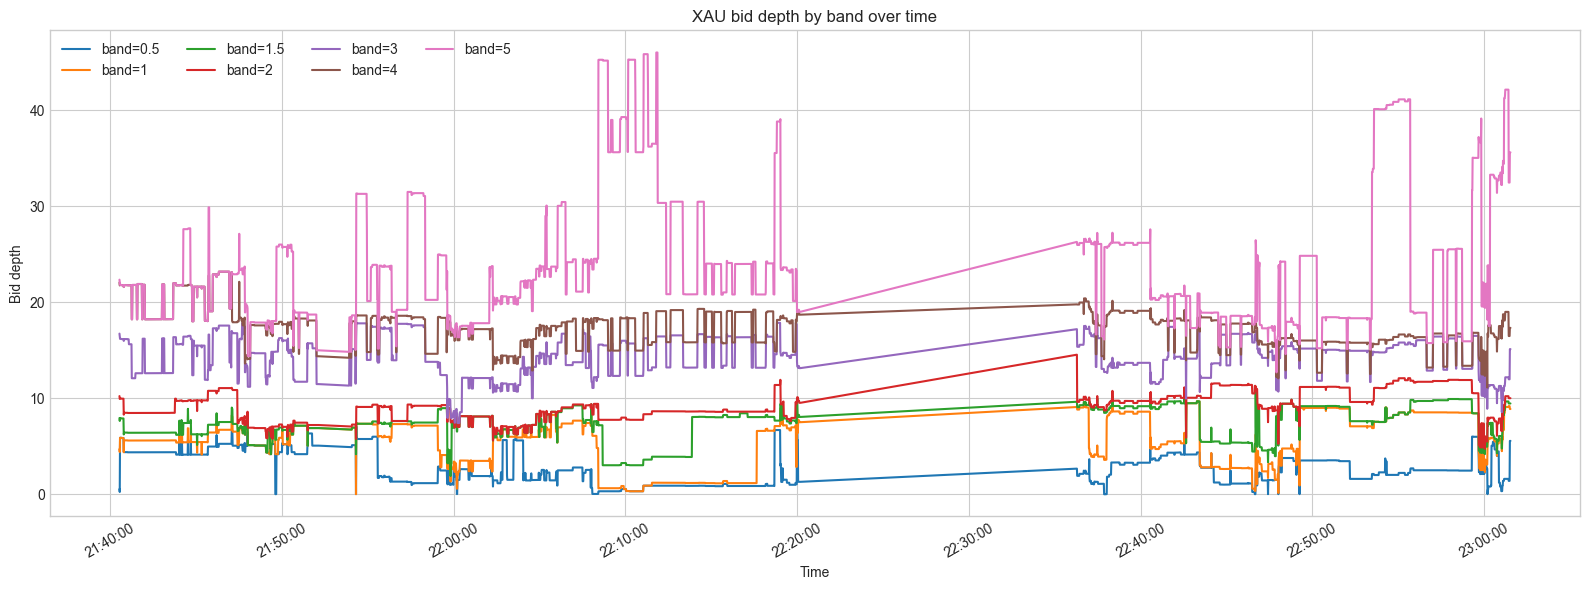

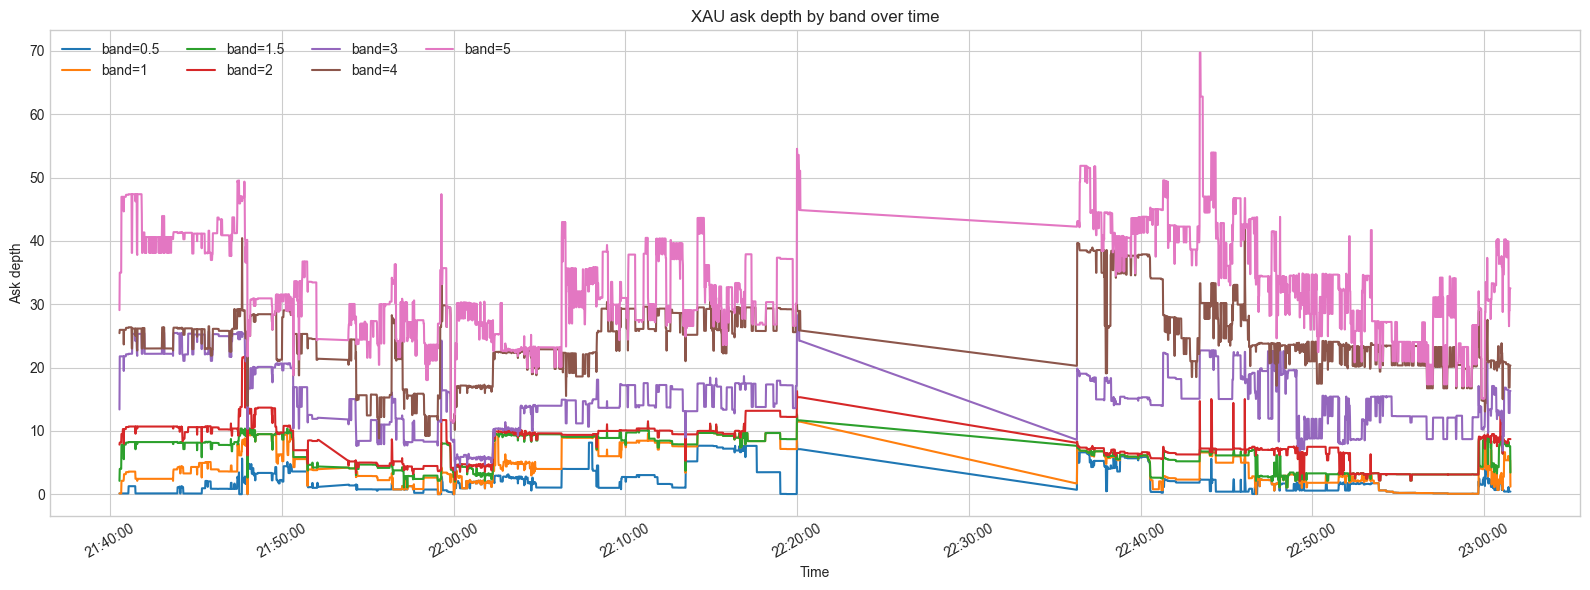

In [89]:
plot_multiband_lines(
    plot_df,
    band_series("bid_depth", DEPTH_BANDS),
    title="XAU bid depth by band over time",
    ylabel="Bid depth",
)

plot_multiband_lines(
    plot_df,
    band_series("ask_depth", DEPTH_BANDS),
    title="XAU ask depth by band over time",
    ylabel="Ask depth",
)

## Chart 2: rolling volatility of bid depth and ask depth

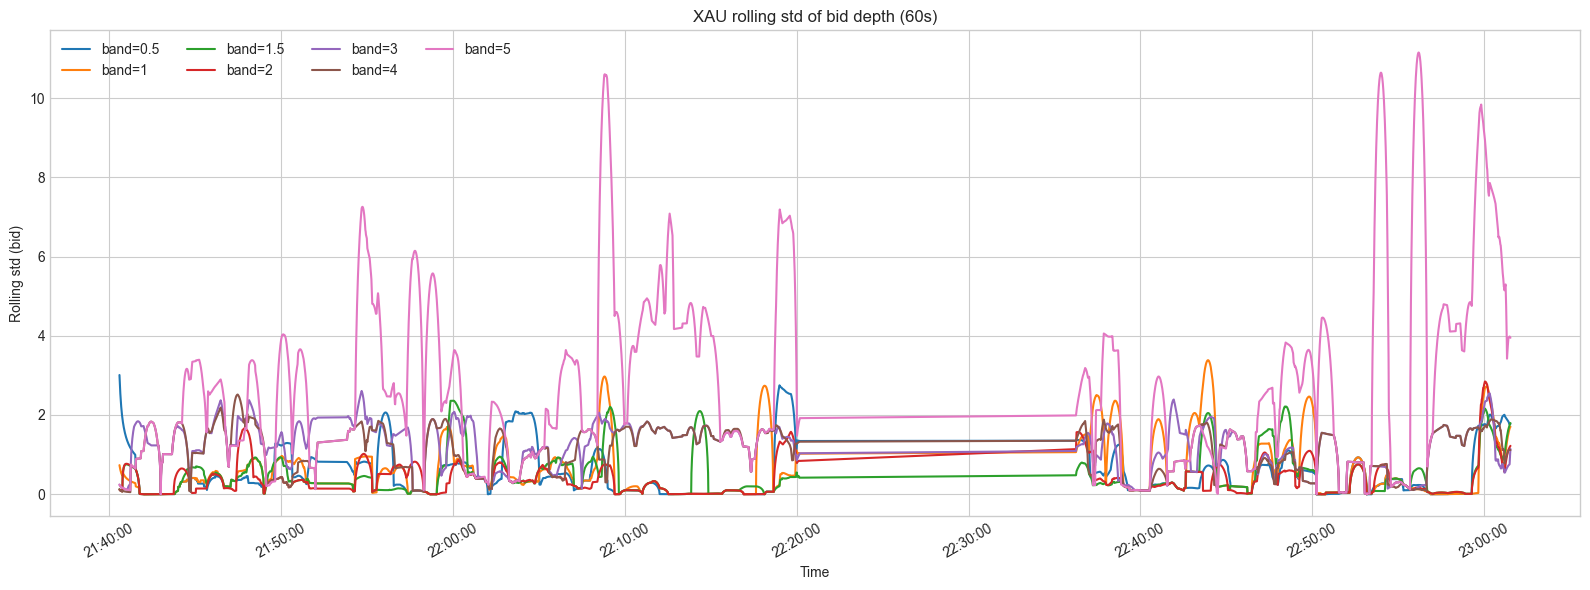

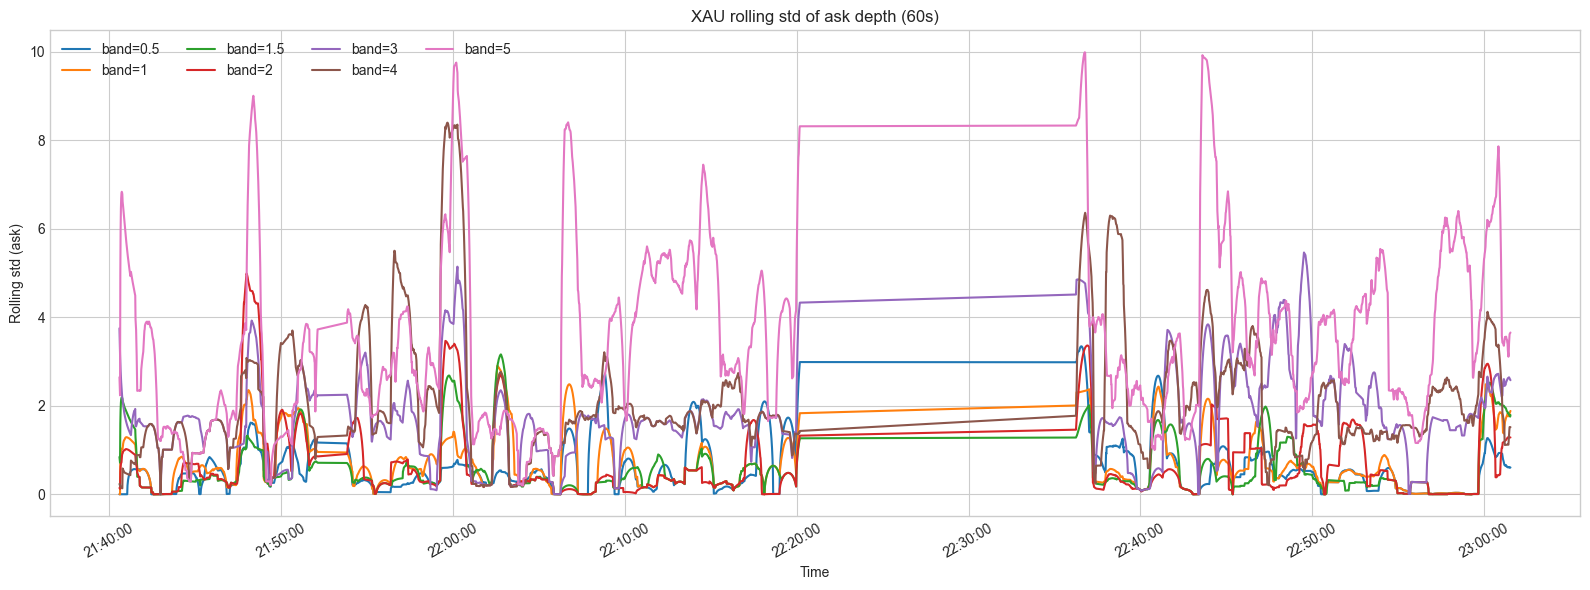

In [90]:
plot_multiband_lines(
    plot_df,
    band_series(f"rolling_std_bid_{DEFAULT_ROLLING_WINDOW}", DEPTH_BANDS),
    title=f"XAU rolling std of bid depth ({DEFAULT_ROLLING_WINDOW})",
    ylabel="Rolling std (bid)",
)

plot_multiband_lines(
    plot_df,
    band_series(f"rolling_std_ask_{DEFAULT_ROLLING_WINDOW}", DEPTH_BANDS),
    title=f"XAU rolling std of ask depth ({DEFAULT_ROLLING_WINDOW})",
    ylabel="Rolling std (ask)",
)

## Chart 3: heatmap of absolute 1-second bid/ask depth change

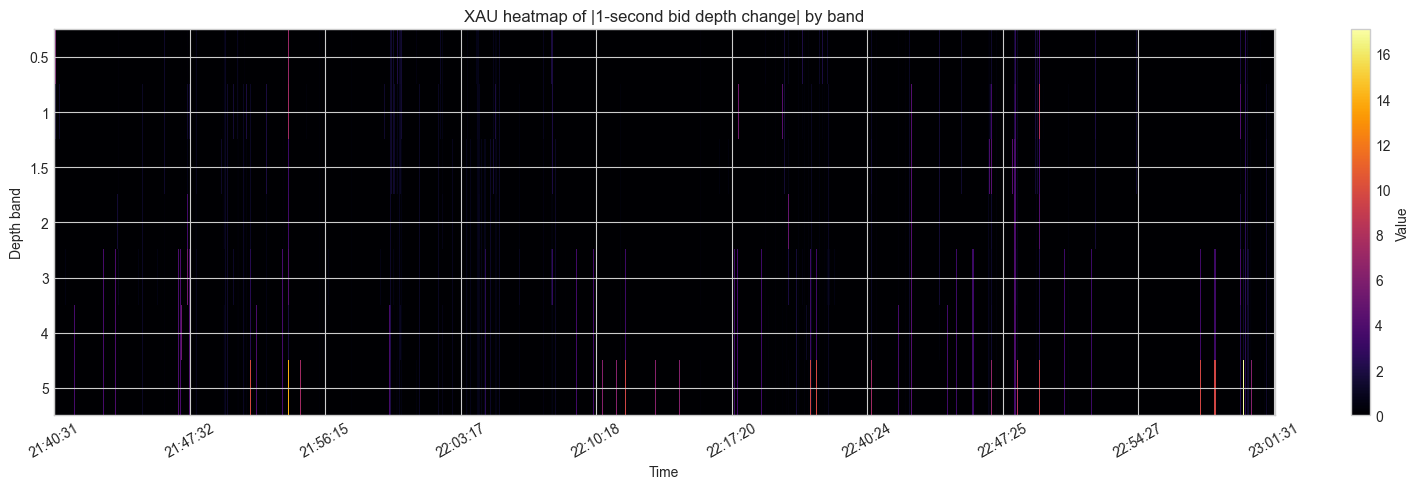

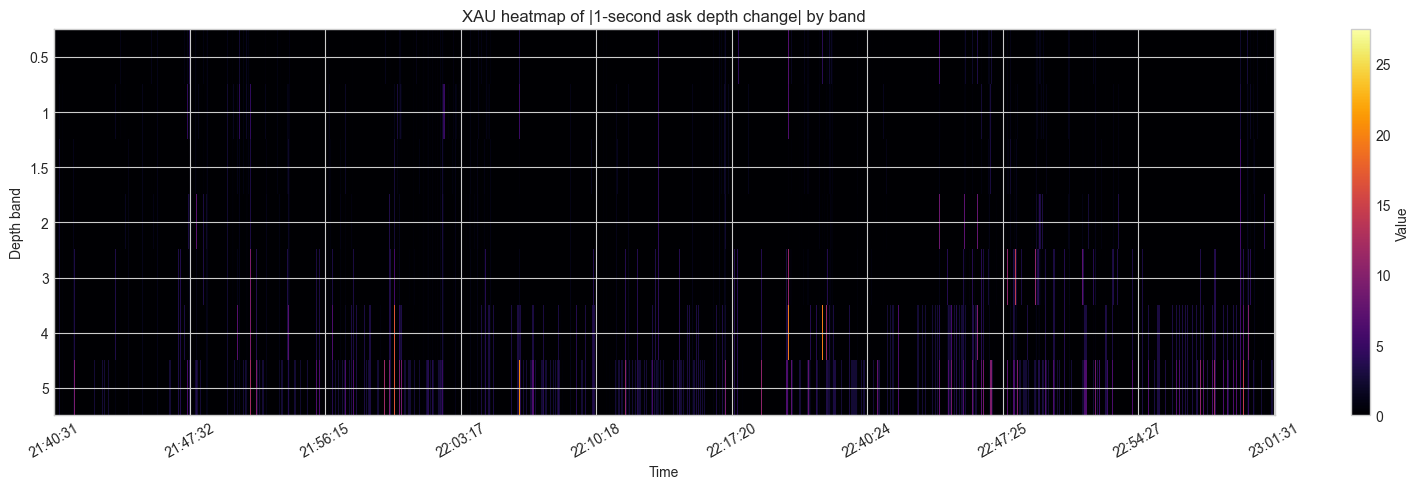

In [91]:
plot_heatmap(
    heatmap_df,
    band_series("abs_bid_depth_change_1s", DEPTH_BANDS),
    title="XAU heatmap of |1-second bid depth change| by band",
    cmap="inferno",
)

plot_heatmap(
    heatmap_df,
    band_series("abs_ask_depth_change_1s", DEPTH_BANDS),
    title="XAU heatmap of |1-second ask depth change| by band",
    cmap="inferno",
)

## Chart 4: spread and bid/ask depth volatility context

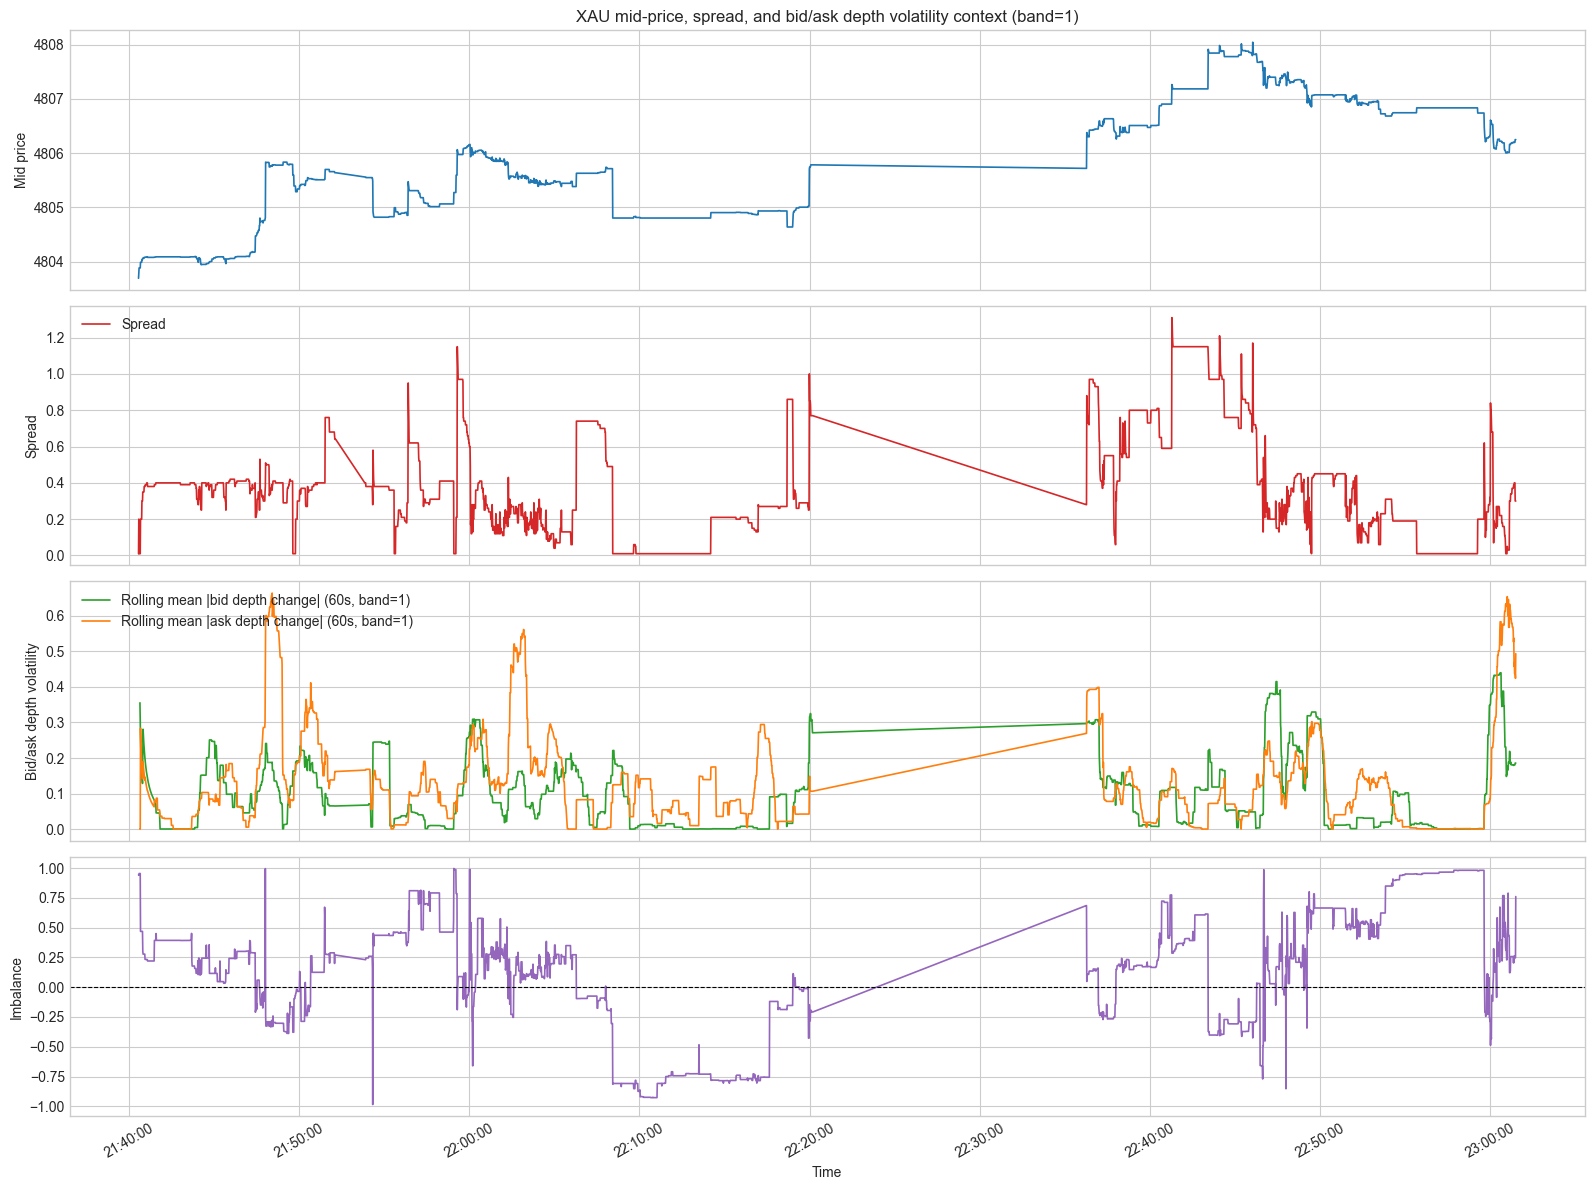

In [92]:
context_suffix = band_label(CONTEXT_BAND)
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(plot_df["timestamp"], plot_df["mid_price"], color="tab:blue", linewidth=1.2)
axes[0].set_title(f"XAU mid-price, spread, and bid/ask depth volatility context (band={CONTEXT_BAND})")
axes[0].set_ylabel("Mid price")

axes[1].plot(plot_df["timestamp"], plot_df["spread"], color="tab:red", linewidth=1.2, label="Spread")
axes[1].set_ylabel("Spread")
axes[1].legend(loc="upper left")

axes[2].plot(
    plot_df["timestamp"],
    plot_df[f"rolling_mean_abs_bid_change_{DEFAULT_ROLLING_WINDOW}_{context_suffix}"],
    color="tab:green",
    linewidth=1.2,
    label=f"Rolling mean |bid depth change| ({DEFAULT_ROLLING_WINDOW}, band={CONTEXT_BAND})",
)
axes[2].plot(
    plot_df["timestamp"],
    plot_df[f"rolling_mean_abs_ask_change_{DEFAULT_ROLLING_WINDOW}_{context_suffix}"],
    color="tab:orange",
    linewidth=1.2,
    label=f"Rolling mean |ask depth change| ({DEFAULT_ROLLING_WINDOW}, band={CONTEXT_BAND})",
)
axes[2].set_ylabel("Bid/ask depth volatility")
axes[2].legend(loc="upper left")

axes[3].plot(
    plot_df["timestamp"],
    plot_df[f"imbalance_{context_suffix}"],
    color="tab:purple",
    linewidth=1.2,
)
axes[3].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[3].set_ylabel("Imbalance")
axes[3].set_xlabel("Time")

format_time_axis(axes[3])
plt.tight_layout()
plt.show()

## Chart 5: separate bid chart and ask chart for key bands

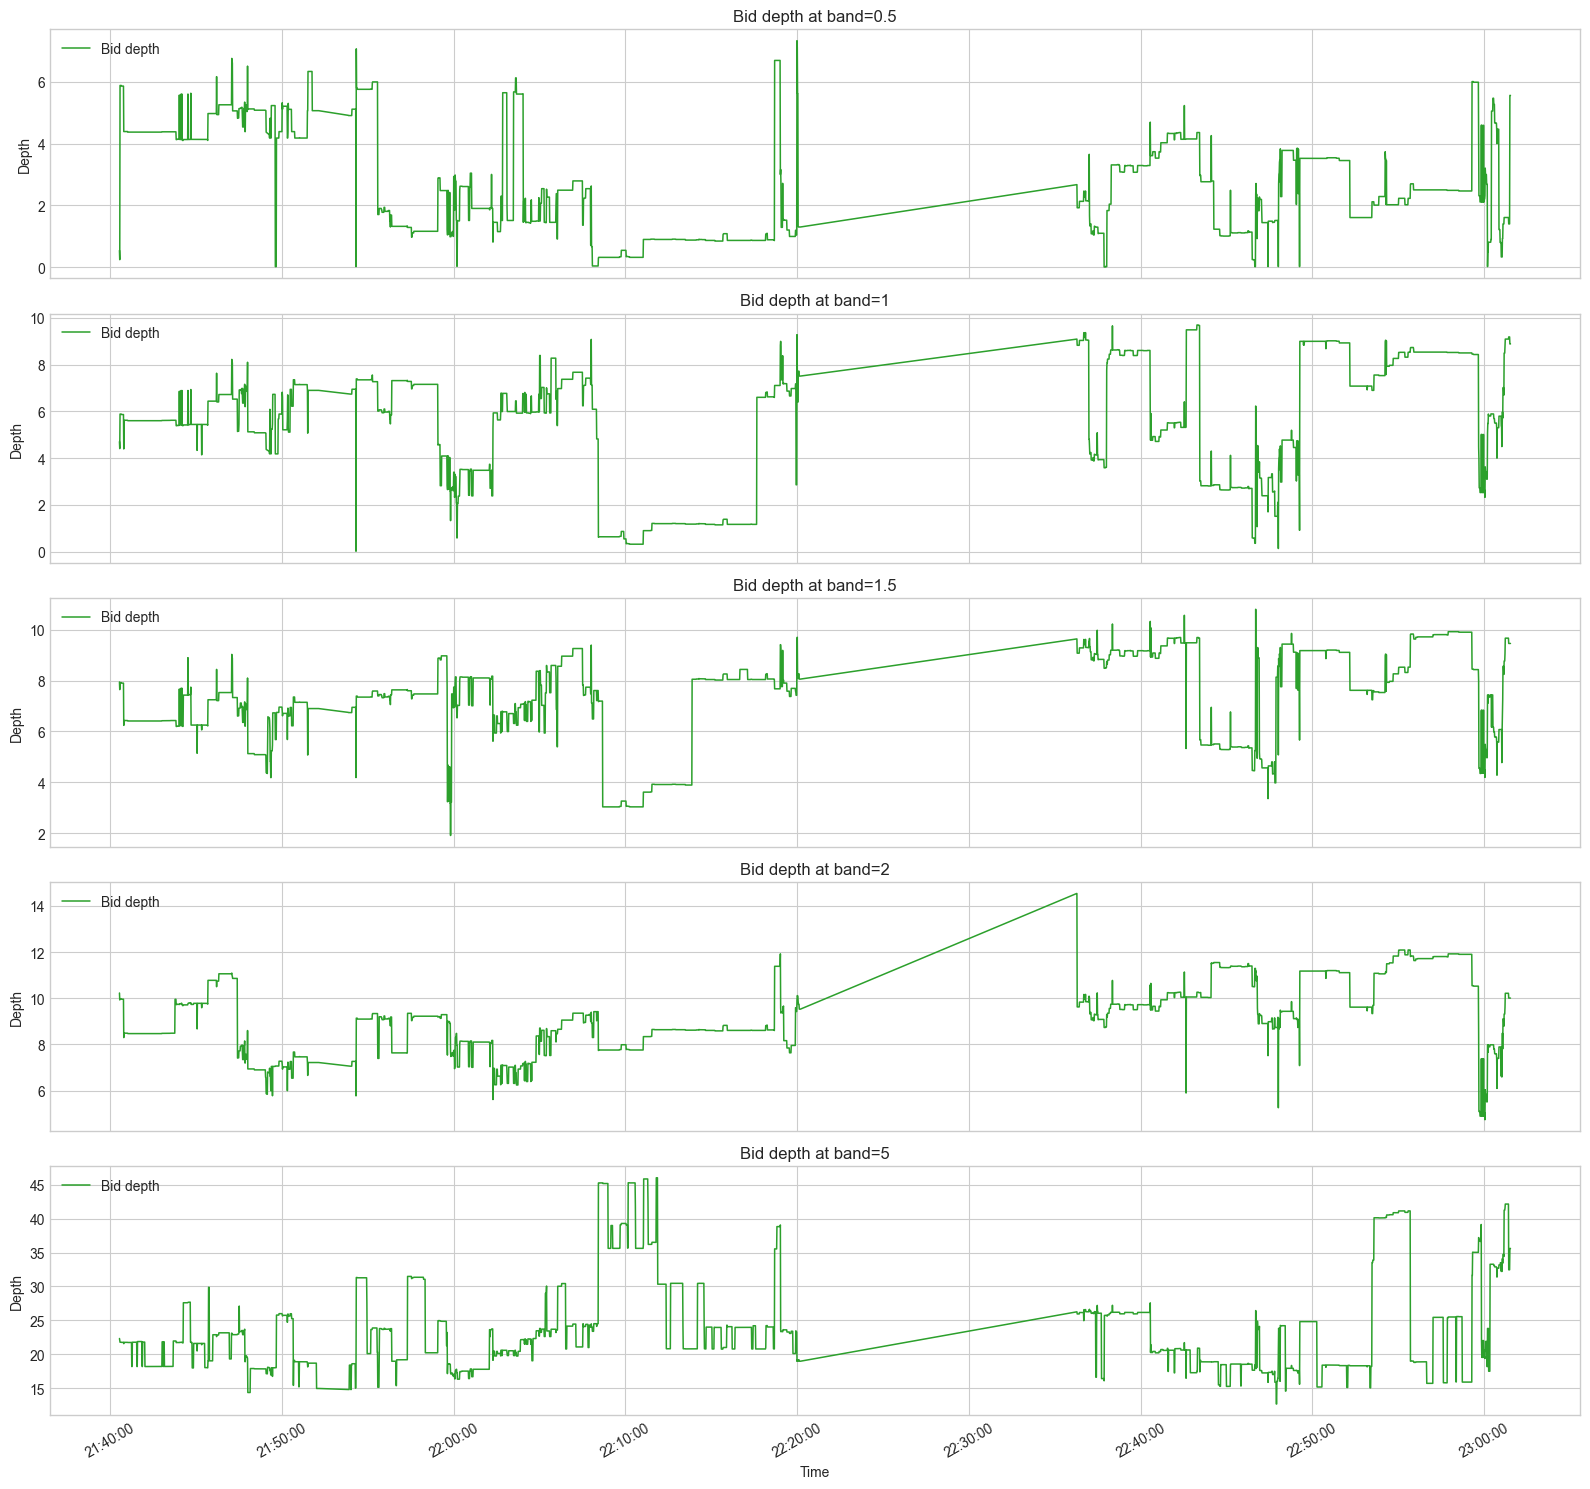

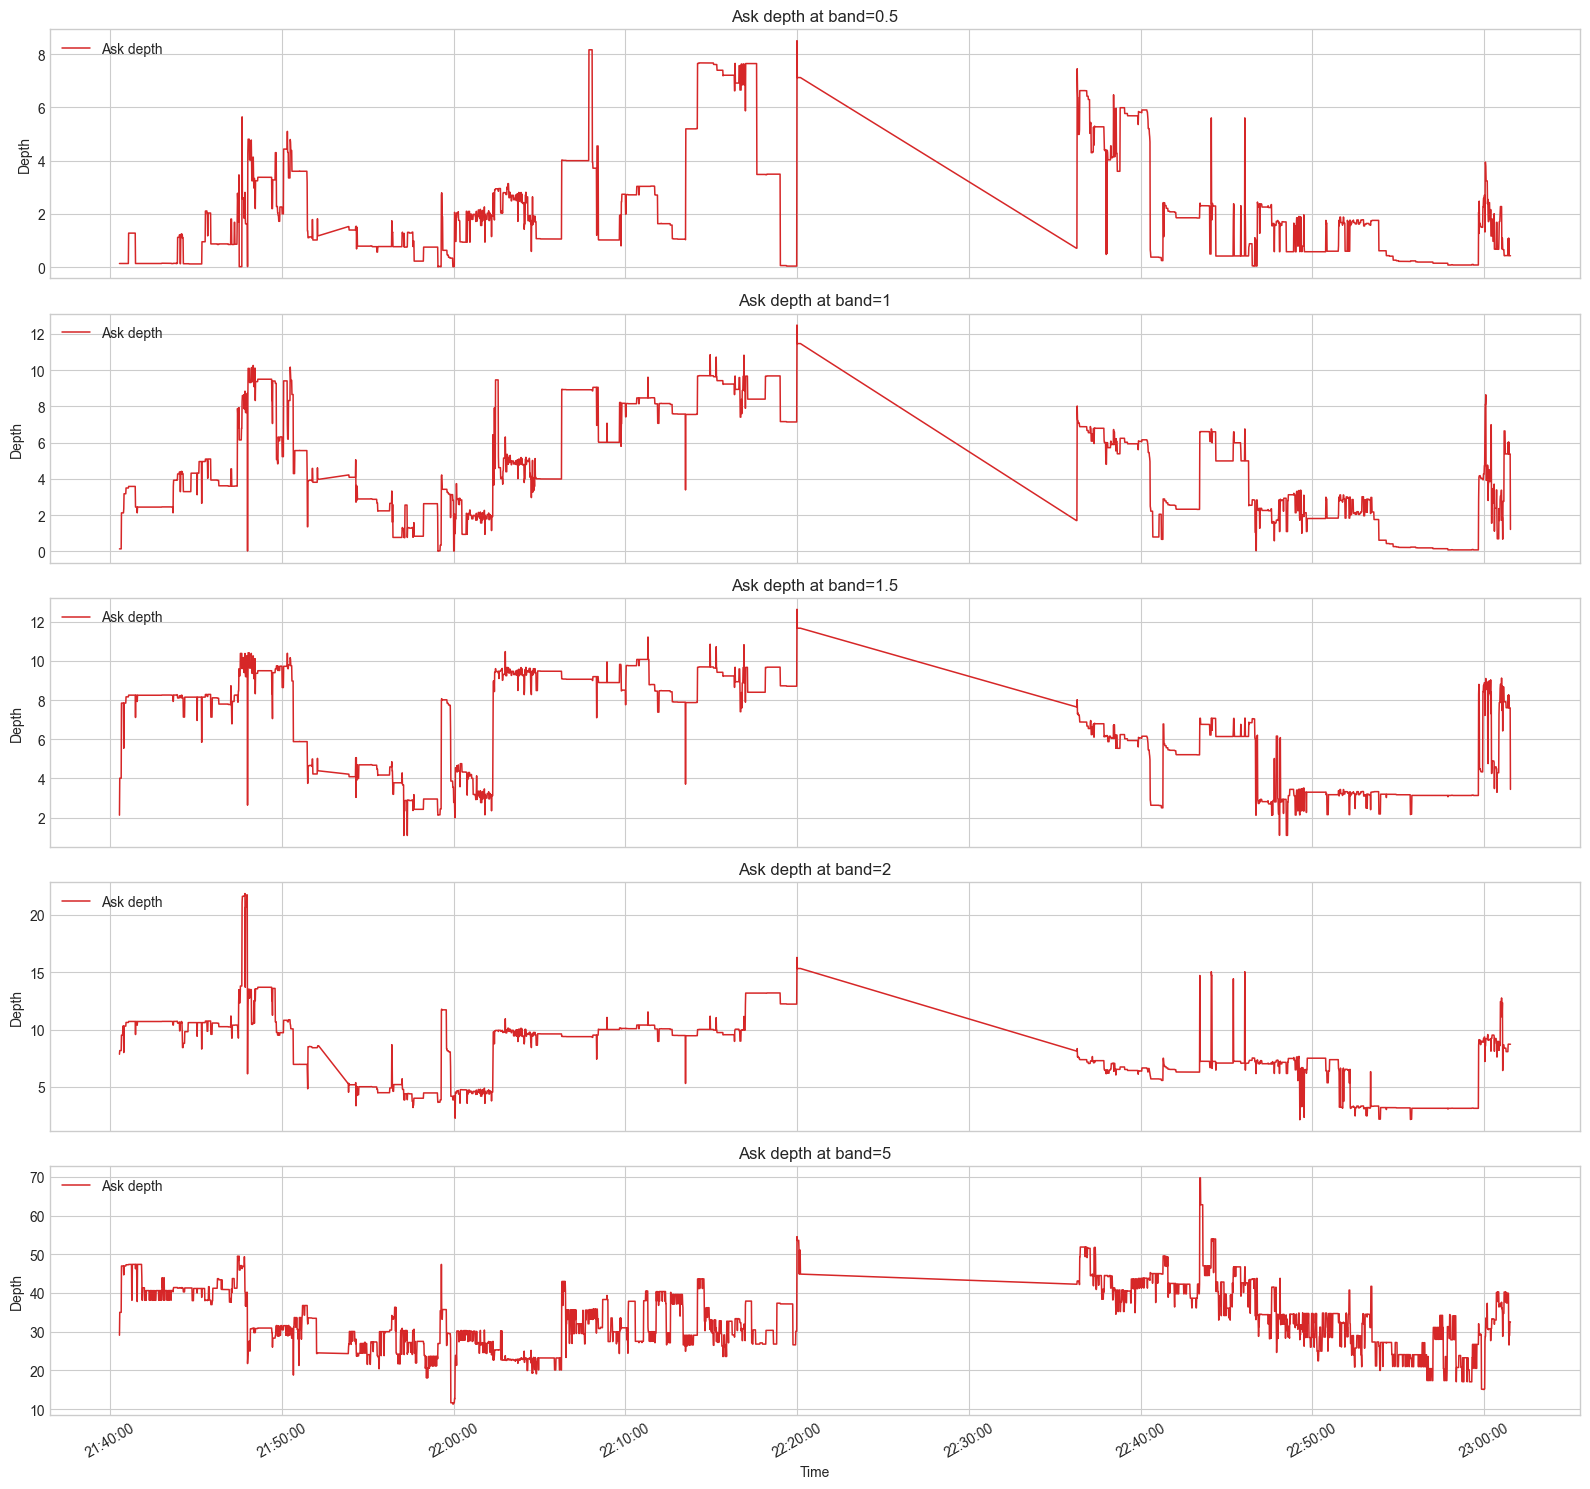

In [93]:
fig, axes = plt.subplots(len(KEY_BANDS), 1, figsize=(16, 3 * len(KEY_BANDS)), sharex=True)
if len(KEY_BANDS) == 1:
    axes = [axes]

for ax, band in zip(axes, KEY_BANDS):
    suffix = band_label(band)
    ax.plot(plot_df["timestamp"], plot_df[f"bid_depth_{suffix}"], color="tab:green", label="Bid depth", linewidth=1.1)
    ax.set_title(f"Bid depth at band={band}")
    ax.set_ylabel("Depth")
    ax.legend(loc="upper left")

format_time_axis(axes[-1])
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(KEY_BANDS), 1, figsize=(16, 3 * len(KEY_BANDS)), sharex=True)
if len(KEY_BANDS) == 1:
    axes = [axes]

for ax, band in zip(axes, KEY_BANDS):
    suffix = band_label(band)
    ax.plot(plot_df["timestamp"], plot_df[f"ask_depth_{suffix}"], color="tab:red", label="Ask depth", linewidth=1.1)
    ax.set_title(f"Ask depth at band={band}")
    ax.set_ylabel("Depth")
    ax.legend(loc="upper left")

format_time_axis(axes[-1])
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Which band is most volatile?

In [94]:
volatility_summary.style.format({
    "mean_total_depth": "{:.4f}",
    "mean_abs_depth_change_1s": "{:.4f}",
    f"mean_rolling_std_{DEFAULT_ROLLING_WINDOW}": "{:.4f}",
    "max_depth_spike": "{:.4f}",
}).background_gradient(subset=["mean_abs_depth_change_1s", f"mean_rolling_std_{DEFAULT_ROLLING_WINDOW}", "max_depth_spike"], cmap="YlOrRd")

,band,mean_total_depth,mean_abs_depth_change_1s,mean_rolling_std_60s,max_depth_spike
0,5.000000,57.1331,1.2946,5.4914,31.2297
1,4.000000,42.0056,0.6570,2.8984,20.6631
2,3.000000,29.7606,0.4274,2.4694,12.7469
3,1.000000,10.0366,0.1955,0.9914,11.7672
4,2.000000,17.1186,0.1738,0.8183,14.3637
5,1.500000,13.7513,0.1698,0.7594,6.3815
6,0.500000,4.7504,0.1560,0.8826,14.7505


## Top depth spikes

In [95]:
spike_frames = []
for band in DEPTH_BANDS:
    suffix = band_label(band)
    spike_frames.append(
        df[["timestamp", "spread", "mid_price", f"total_depth_{suffix}", f"abs_depth_change_1s_{suffix}"]]
        .rename(
            columns={
                f"total_depth_{suffix}": "total_depth",
                f"abs_depth_change_1s_{suffix}": "abs_depth_change_1s",
            }
        )
        .assign(band=band)
    )

top_spikes = (
    pd.concat(spike_frames, ignore_index=True)
    .sort_values("abs_depth_change_1s", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_spikes

,timestamp,spread,mid_price,total_depth,abs_depth_change_1s,band
0,2026-04-19 22:59:50.481000+07:00,0.24,4806.280,37.1794,31.2297,5.0
1,2026-04-19 22:14:11.958000+07:00,0.21,4804.905,74.0717,24.1658,5.0
2,2026-04-19 22:43:26.509000+07:00,1.11,4807.915,87.1590,23.9652,5.0
3,2026-04-19 22:55:42.228000+07:00,0.01,4806.835,42.0680,23.1253,5.0
4,2026-04-19 22:12:37.863000+07:00,0.01,4804.805,70.6028,22.6449,5.0
5,2026-04-19 22:59:17.445000+07:00,0.20,4806.740,54.9083,21.9293,5.0
6,2026-04-19 21:50:40.088000+07:00,0.36,4805.530,34.2283,21.8384,5.0
7,2026-04-19 22:06:17.500000+07:00,0.74,4805.630,70.9157,20.7802,5.0
8,2026-04-19 22:38:01.208000+07:00,0.35,4806.375,57.2372,20.6631,4.0
9,2026-04-19 23:01:25.590000+07:00,0.39,4806.195,61.5039,20.5439,5.0


## Optional: resample for readability when the series gets longer

In [96]:
resampled = (
    df.set_index("timestamp")
    .resample("10S")
    .agg({
        **{f"total_depth_{band_label(band)}": "mean" for band in DEPTH_BANDS},
        **{f"rolling_std_{DEFAULT_ROLLING_WINDOW}_{band_label(band)}": "mean" for band in DEPTH_BANDS},
        "spread": "mean",
        "mid_price": "last",
    })
    .dropna(how="all")
    .reset_index()
)
resampled.head()

ValueError: Invalid frequency: 10S. Failed to parse with error message: ValueError("Invalid frequency: S. Failed to parse with error message: KeyError('S'). Did you mean s?")

Nếu dữ liệu dài hơn, có thể thay `df` bằng `resampled` trong các hàm plot để đọc chart dễ hơn mà vẫn giữ được cấu trúc phân tích.